# The action agent, start to finish

This notebook walks through the final agent model from this repository —
the one that decides **where to move next** while reaching goals and
avoiding moving obstacles — and trains it from scratch on expert
demonstrations, then tests it and demonstrates its selection-history
signature.

It is the companion of `Visual-Search/tutorial_visual_search.ipynb`.
The two models share one theory — everything the agent senses, wants,
and remembers is written into a single spatial field, and one readout
selects the action — realized in two very different bodies:

| | visual search | action agent |
| --- | --- | --- |
| coordinate frame | retinotopic pixels | 360 rays around the agent |
| bottom-up source | color/shape contrast maps | obstacle sense (looming psychophysics) |
| top-down source | goal-weighted color evidence | goal field (gain x cosine geometry) |
| history source | target/distractor memory traces | remembered goal-location field |
| readout | softmax over items -> a saccade | planner network -> a movement |

**Input and output.** Each step the agent receives: two consecutive
LiDAR scans (360 distances each), the vector to the visible goal, and
the vector to its remembered goal location. It returns a 2D movement.

**Before running:** generate the demonstrations once:

    python3 expert_goal.py --num_features 360 --num_episodes 20 \
      --max_steps_per_episode 3000 --record_every 5 --goal_free_steps 0 \
      --goal_bias none --output dataset/data_goal_unbiased_360.csv

Needs `numpy`, `pandas`, `matplotlib`, `torch`. Training takes under a
minute; the evaluation cells a few minutes each.

In [1]:
import math
import random
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
import torch

from model.goal_es2 import GoalEs2Model
from environment import (GOAL_RADIUS, CollisionTracker,
                                lidar_scan, make_world, sample_goal)

torch.manual_seed(0)
random.seed(0)
W = H = 800

## 1. The model, with a diagram

The equation, in words. For each of 360 directions around the agent:

    field(direction) = obstacle sense(direction)
                       + goal field(direction)
                       + beta_H x history field(direction)

    movement = planner(field)

Every source flows into one ego-centered field; a small network reads
the field out as a movement. Two honest notes:

- **The channel gains are curves, not scalars.** In the search model
  each channel has one readable gain (`g_C`, `g_F`). Here the goal and
  history fields carry a learned **gain-vs-distance curve** (a tiny
  MLP), and the obstacle pathway a learned per-ray sensitivity `k`
  inside a fixed sigmoid. All three are the same kind of object — a
  psychophysical transfer function from a physical variable to signal
  strength: the obstacle curve transduces *physics* (distance, approach
  -> perceived urgency), the goal and history curves transduce
  *relevance* (distance -> pull). Comparing channels means comparing
  curves, not numbers.
- **There is no attention window here, and none in the search model
  either.** What the original ES2 paper called an "attention field" is
  the psychophysical transform above — part of building the sensory
  field, not a gate over a finished one. Recognizing that is what let
  the search model drop its window.

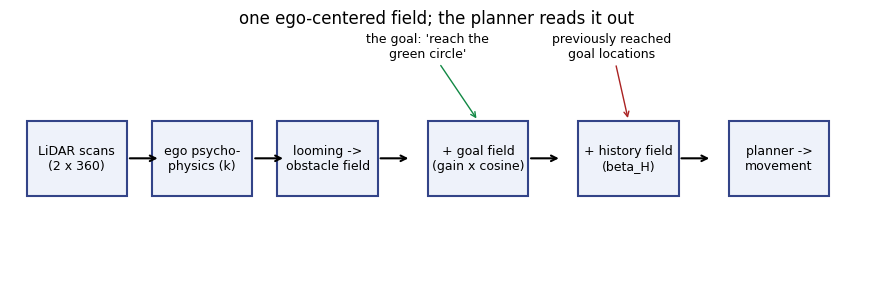

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.02, "LiDAR scans\n(2 x 360)"),
         (0.17, "ego psycho-\nphysics (k)"),
         (0.32, "looming ->\nobstacle field"),
         (0.50, "+ goal field\n(gain x cosine)"),
         (0.68, "+ history field\n(beta_H)"),
         (0.86, "planner ->\nmovement")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.12, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.06, 0.51, label, ha="center", va="center", fontsize=9)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.16, 0.51), xytext=(x + 0.12, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'reach the\ngreen circle'", xy=(0.56, 0.67),
            xytext=(0.50, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previously reached\ngoal locations", xy=(0.74, 0.67),
            xytext=(0.72, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05); ax.axis("off")
plt.title("one ego-centered field; the planner reads it out")
plt.show()

## 2. Building it piece by piece

### 2a. From distances to perceived closeness

The agent senses the world as 360 LiDAR rays. The first stage is pure
psychophysics: each distance passes through a sigmoid with learned
sensitivity `k`,

    sense(d) = 2 * (1 - sigmoid(k * d))    in (0, 2)

so **near is strong, far is weak**, saturating at both ends — a
Weber-style compression of physical distance into signal. Below: an
example world, its raw scan, and the transformed scan (`k` at its
initialization; training tunes one `k` per ray).

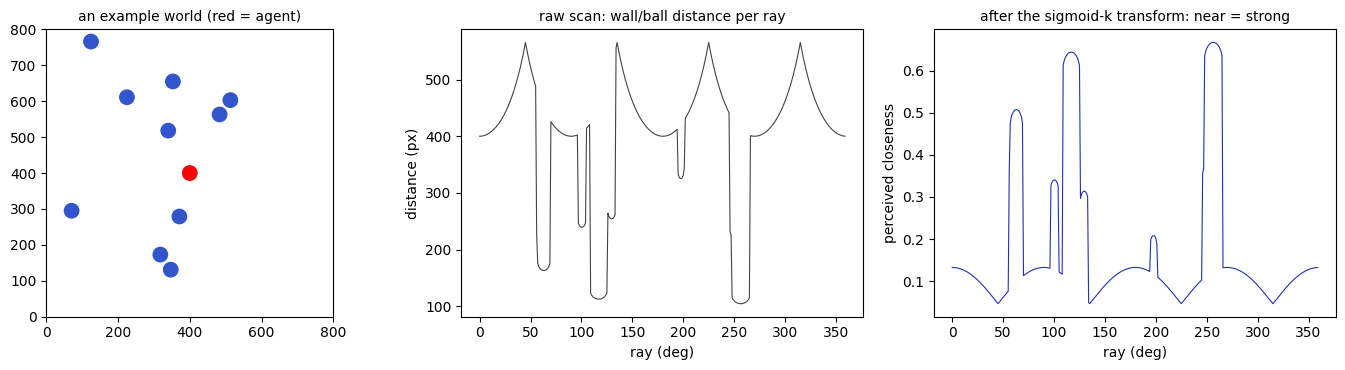

In [3]:
player, balls = make_world(10, W, H)
distances, _ = lidar_scan(player, balls, W, H, 360)
demo = GoalEs2Model(num_features=360)          # untrained: for the transform shape
with torch.no_grad():
    sensed = demo.spatial_sense_block.sigmoid(torch.tensor(distances)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].add_patch(plt.Circle((player.x, player.y), player.radius, color="red"))
for b in balls:
    if b is not player:
        axes[0].add_patch(plt.Circle((b.x, b.y), b.radius, color="#3355cc"))
axes[0].set_xlim(0, W); axes[0].set_ylim(0, H); axes[0].set_aspect(1)
axes[0].set_title("an example world (red = agent)", fontsize=10)
axes[1].plot(distances, color="#444444", lw=0.8)
axes[1].set_xlabel("ray (deg)"); axes[1].set_ylabel("distance (px)")
axes[1].set_title("raw scan: wall/ball distance per ray", fontsize=10)
axes[2].plot(sensed, color="#2233aa", lw=0.8)
axes[2].set_xlabel("ray (deg)"); axes[2].set_ylabel("perceived closeness")
axes[2].set_title("after the sigmoid-k transform: near = strong", fontsize=10)
plt.tight_layout()
plt.show()

### 2b. Looming: change is the signal

One frame of closeness says little about danger — a near wall is near
forever. The obstacle field is driven by **looming**, the change in
perceived closeness between two consecutive scans, scaled by current
closeness:

    obstacle(direction) = proj(sense_now - sense_before) * sense_now

Directions where something is **approaching** light up; static
surroundings cancel out. (The projection is two stacked linear layers —
an implicit learned gain on the looming signal.)

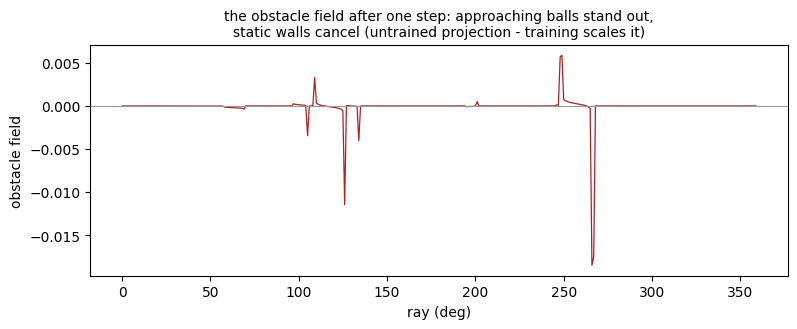

In [4]:
for b in balls:
    if b is not player:
        b.move()
distances2, _ = lidar_scan(player, balls, W, H, 360)
with torch.no_grad():
    obs_field = demo.spatial_sense_block(
        torch.tensor(distances + distances2, dtype=torch.float32).unsqueeze(0)
    )[0].numpy()

plt.figure(figsize=(9, 3))
plt.plot(obs_field, color="#aa2222", lw=0.9)
plt.axhline(0, color="#999999", lw=0.8)
plt.xlabel("ray (deg)"); plt.ylabel("obstacle field")
plt.title("the obstacle field after one step: approaching balls stand out,\n"
          "static walls cancel (untrained projection - training scales it)",
          fontsize=10)
plt.show()

### 2c. The goal and history fields: same construction, different meaning

A single location — the visible goal, or the remembered one — becomes a
field in two factors:

    field(direction) = gain(distance) * cos(direction - bearing)

The cosine is fixed geometry: strongest toward the location, zero
sideways, negative behind. The gain is the learned relevance curve.
The history field is the identical construction applied to the
remembered location, scaled by one strength `beta_H` — exactly the
search model's `beta_T x G(x - x_j)`: one spatial kernel, one strength
per source.

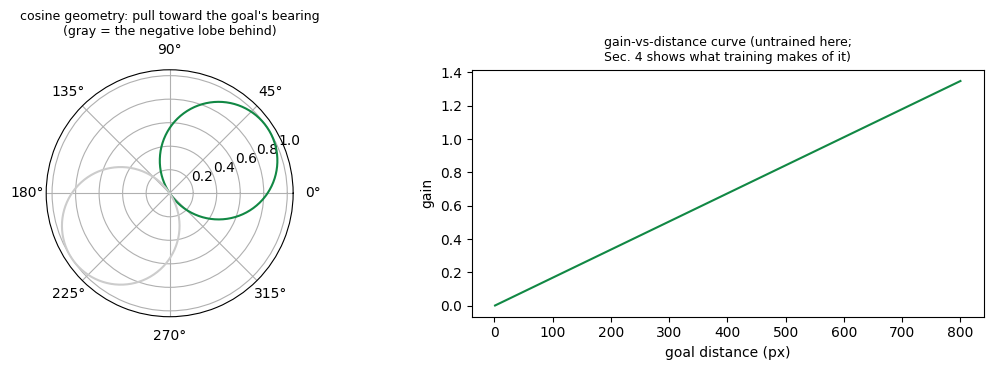

In [5]:
goal_vec = torch.tensor([[300.0, 200.0]])       # a goal up-right of the agent
alignment = (goal_vec[0, 0] / goal_vec.norm() * demo.ray_cos
             + goal_vec[0, 1] / goal_vec.norm() * demo.ray_sin).numpy()
ang = np.deg2rad(np.arange(360))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         subplot_kw=dict(projection="polar"))
axes[0].plot(ang, np.maximum(alignment, 0), color="#118844")
axes[0].plot(ang, np.maximum(-alignment, 0), color="#cccccc")
axes[0].set_title("cosine geometry: pull toward the goal's bearing\n"
                  "(gray = the negative lobe behind)", fontsize=9)
with torch.no_grad():
    d_axis = torch.linspace(1, 800, 100).unsqueeze(1)
    g_curve = demo.goal_gain(d_axis / demo.sensing_range).squeeze(1).numpy()
axes[1].remove()
ax = fig.add_subplot(1, 2, 2)
ax.plot(d_axis.squeeze(1).numpy(), g_curve, color="#118844")
ax.set_xlabel("goal distance (px)"); ax.set_ylabel("gain")
ax.set_title("gain-vs-distance curve (untrained here;\n"
             "Sec. 4 shows what training makes of it)", fontsize=9)
plt.tight_layout()
plt.show()

## 3. The whole model in five lines

Not a re-implementation — the actual forward pass, imported from
`model/goal_history_es2.py`:

In [6]:
import inspect
print(inspect.getsource(GoalEs2Model.compute_fields))
print(inspect.getsource(GoalEs2Model.forward))

    def compute_fields(self, input):
        scan_input = input[:, : 2 * self.num_features]
        goal = input[:, 2 * self.num_features : 2 * self.num_features + 2]
        hist = input[:, 2 * self.num_features + 2 :]

        obstacle_field = self.spatial_sense_block(scan_input)
        goal_field = self.geometric_field(goal, self.goal_gain)
        history_field = self.geometric_field(hist, self.history_gain)
        return obstacle_field, goal_field, history_field

    def forward(self, input):
        obstacle_field, goal_field, history_field = self.compute_fields(input)
        field = obstacle_field + goal_field + self.beta_H * history_field
        return self.sense_action_layers(field)



## 4. Train on the expert demonstrations

The dataset holds 12,000 recorded steps of a scripted expert playing
the continuous task — reach the green goal, dodge the balls, a new
goal spawns on arrival (1,316 goals, 0 collisions; 65.8 goals/min).
We clone it: match the expert's movement at every recorded step by
gradient descent — the same mini-batch recipe as every model in this
repository (batch 64, Adam, MSE; 150 epochs, a few minutes).

**History is disabled during training** (`beta_H` frozen at 0) — this
is the model of record. The reason is principled, not incidental, and
Section 7 is about it: this expert never uses its memory, so cloning
can attribute nothing to the history channel; leaving the channel
free only lets it chase noise (it fits better in-sample and behaves
worse in rollout — the record for that ablation is in
`RESULTS_goal_es2.md`).

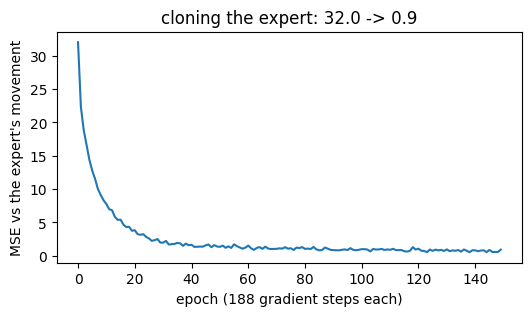

In [7]:
from dataset.dataloader_goal import get_goal_data

data_loader = get_goal_data(
    file_path="dataset/data_goal_unbiased_360.csv",
    scan_columns=[f"scan_{i}" for i in range(360)],
    goal_columns=["goal_dx", "goal_dy"],
    target_columns=["fx", "fy"],
    batch_size=64,
    device="cpu",
)

model = GoalEs2Model(num_features=360)
with torch.no_grad():
    model.beta_H.zero_()
model.beta_H.requires_grad = False              # history disabled: Sec. 7

optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=0.001)
criterion = torch.nn.MSELoss()
losses = []
for epoch in range(150):
    total = 0.0
    for inputs, targets in data_loader:
        optimizer.zero_grad()
        # the history slot is fed zeros - beta_H is 0, it never matters
        inputs = torch.cat([inputs, torch.zeros(inputs.size(0), 2)], dim=1)
        loss = criterion(model(inputs), targets)
        loss.backward()
        optimizer.step()
        total += loss.item()
    losses.append(total / len(data_loader))

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("epoch (188 gradient steps each)")
plt.ylabel("MSE vs the expert's movement")
plt.title(f"cloning the expert: {losses[0]:.1f} -> {losses[-1]:.1f}")
plt.show()

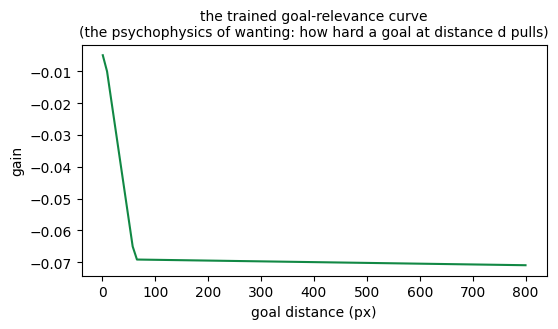

beta_H = +0.000 (frozen: history disabled)


In [8]:
with torch.no_grad():
    d_axis = torch.linspace(1, 800, 100).unsqueeze(1)
    g_curve = model.goal_gain(d_axis / model.sensing_range).squeeze(1).numpy()
plt.figure(figsize=(6, 3))
plt.plot(d_axis.squeeze(1).numpy(), g_curve, color="#118844")
plt.xlabel("goal distance (px)"); plt.ylabel("gain")
plt.title("the trained goal-relevance curve\n"
          "(the psychophysics of wanting: how hard a goal at distance d pulls)",
          fontsize=10)
plt.show()
print(f"beta_H = {model.beta_H.item():+.3f} (frozen: history disabled)")

## 5. How good is it?

The evaluation of record mirrors the demonstrations exactly: a
persistent world, unbiased goals, a new goal on every arrival —
scored as **goals per minute** and **collisions per minute**, against
the expert's own 65.8 and 0.0. (Two seeds here for speed; the ledger's
three-seed numbers: model 68.0 goals/min, 0.0 collisions/min — the
clone matches its teacher.)

In [9]:
from evaluate_goal_es2 import run_seed as eval_run_seed

def eval_args(**over):
    base = dict(num_features=360, num_actions=2, sensing_range=800.0,
                num_balls=10, width=W, height=H, max_speed=10.0,
                max_steps=6000, goal_free_steps=0, goal_timeout=300,
                goal_bias="none", bias_p=0.8, min_spawn_dist=250,
                speed_multiplier=1.0, respawn_center=False,
                spawn_from_center=False)
    base.update(over)
    return SimpleNamespace(**base)

rows = [eval_run_seed(model, eval_args(), 42 + i) for i in range(2)]
g = np.mean([r["goals_per_min"] for r in rows])
c = np.mean([r["collisions_per_min"] for r in rows])
print(f"model:  {g:.1f} goals/min, {c:.1f} collisions/min")
print("expert: 65.8 goals/min, 0.0 collisions/min")

model:  61.8 goals/min, 0.0 collisions/min
expert: 65.8 goals/min, 0.0 collisions/min


## 6. Does it generalize? Never-seen testing scenarios

The demonstrations contain exactly one regime: 10 balls at speeds 1-3
px/step. Two stress axes probe what the learned field does outside it
(one seed per condition here; three-seed numbers from the ledger in
the titles):

- **Density**: 40 balls is 4x the crowding ever demonstrated.
- **Speed**: multiplying every ball's velocity stresses the looming
  channel, whose signal scales with speed.

And the field model does not stand alone: the repository's two
goal-conditioned baselines — an MLP over the raw 722-vector and a
transformer over it as a token sequence — were retrained on the SAME
demonstrations with the SAME recipe (batch 64, Adam, MSE, 500 epochs on
the cluster) and swept over the same conditions. The cell after next
loads those recorded results (`results_compare/`; nothing retrains
here). The transformer needed a GPU (L40S; ~38 h projected on CPU), so
its wall-clock is not hardware-comparable — the loss-by-epoch axis is.

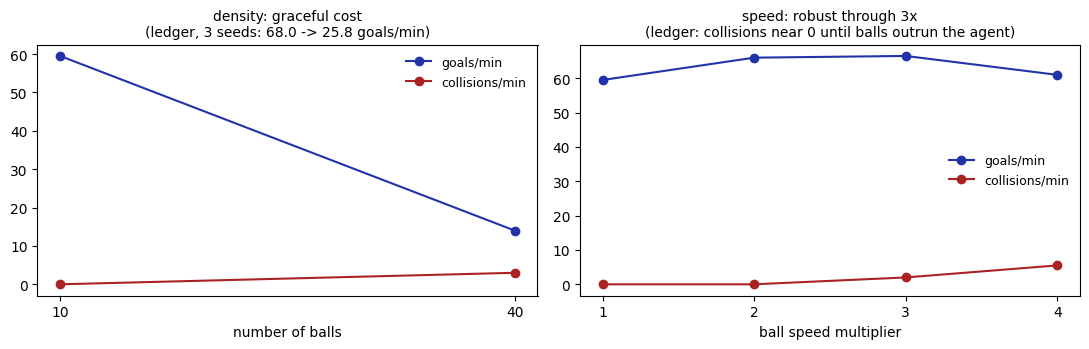

In [10]:
dens_x, dens_g, dens_c = [10, 40], [], []
for nb_ in dens_x:
    r = eval_run_seed(model, eval_args(num_balls=nb_), 42)
    dens_g.append(r["goals_per_min"]); dens_c.append(r["collisions_per_min"])
spd_x, spd_g, spd_c = [1, 2, 3, 4], [], []
for k_ in spd_x:
    r = eval_run_seed(model, eval_args(speed_multiplier=float(k_)), 42)
    spd_g.append(r["goals_per_min"]); spd_c.append(r["collisions_per_min"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, xs, gs, cs, xl, ttl in [
        (axes[0], dens_x, dens_g, dens_c, "number of balls",
         "density: graceful cost\n(ledger, 3 seeds: 68.0 -> 25.8 goals/min)"),
        (axes[1], spd_x, spd_g, spd_c, "ball speed multiplier",
         "speed: robust through 3x\n(ledger: collisions near 0 until balls outrun the agent)")]:
    ax.plot(xs, gs, "o-", color="#2233aa", label="goals/min")
    ax.plot(xs, cs, "o-", color="#aa2222", label="collisions/min")
    ax.set_xlabel(xl); ax.set_title(ttl, fontsize=10)
    ax.set_xticks(xs); ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Density degrades gracefully (paths lengthen, some contact becomes
unavoidable); speed barely hurts until 4x, where the fastest balls
are simply faster than the agent. That asymmetry is diagnostic: the
looming transform extrapolates (its signal stays monotone in speed),
so the *perception* generalizes — the costs appear only where the
*world* stops being solvable the demonstrated way.

## 7. Selection history

### 7a. Why the clone has none — and why that is correct

The search model's history parameters were **fitted to humans**, and
humans carry selection history: priming is in the data, so the fit
finds `beta_T > 0`. Here the "participant" is a scripted expert that
never consults its memory — so behavioral cloning *correctly* finds
nothing for the history channel to explain. (Forcing it: training the
expert to drift toward its memory during goal-free waits teaches
**probability cueing** — anticipatory orienting to a likely region —
which is a different phenomenon than priming, and the cloned drift
comes out shrunken and fragile. The full negative record is in
`RESULTS_goal_es2.md`.)

### 7b. Mechanism sufficiency: priming from one parameter

So the claim is made the way the search model itself makes it: history
is a small parametric mechanism **added** to the competent machinery.
The remembered location (the previous goal — a one-back trace) is fed
through the **trained goal machinery** as a faint goal:

    field += beta_H * geometric_field(remembered - position, goal_gain)

Nothing is trained; the single scalar `beta_H` is swept, with 0 as the
built-in control. Trials mirror the search tutorial's Sec. 9c:
teleport to center, a goal-free anticipation window, then the goal
appears — at the **repeated** location or a **changed** one at matched
eccentricity. If the mechanism is right, one parameter should produce
*both* signatures: priming when the goal is present, anticipatory
drift when it is not.

training on identical footing (500 epochs = 94,000 updates each):
  goal ES2 (field model)   final MSE  0.044   wall-clock 10:09 (8 CPUs)   rollout 62.8 goals/min, 0.0 collisions/min
  goal MLP                 final MSE  0.111   wall-clock 7:25 (8 CPUs)   rollout 38.0 goals/min, 2.2 collisions/min
  goal transformer         final MSE  3.593   wall-clock 45:44 (L40S GPU)   rollout 53.5 goals/min, 0.0 collisions/min


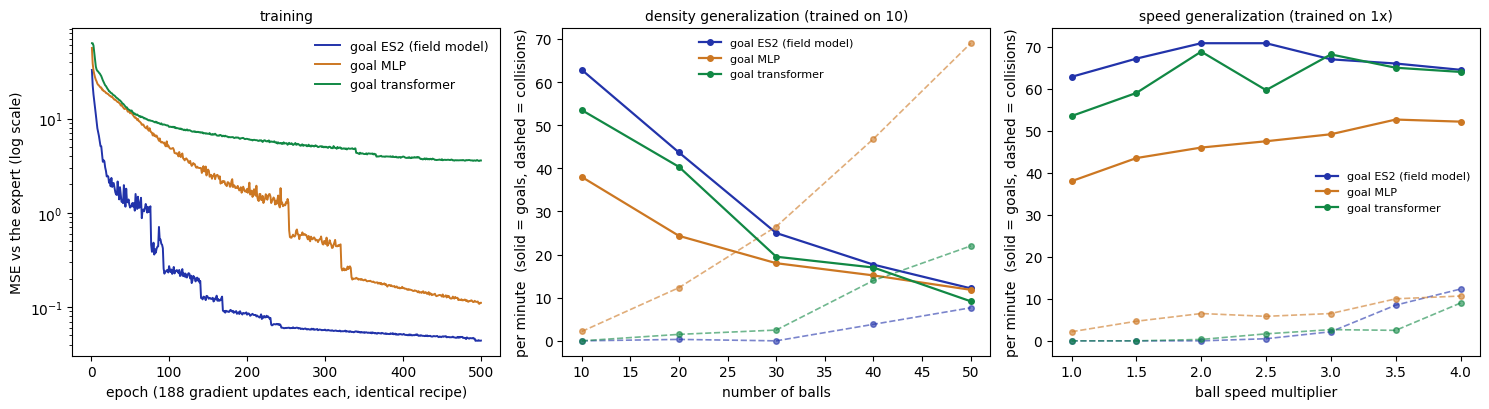

In [12]:
# recorded results: the three models retrained on the cluster on identical
# footing (500 epochs, same recipe); no training happens in this notebook
import csv
import glob

import matplotlib.pyplot as plt

colors = {"es2": "#2233aa", "mlp": "#cc7722", "transformer": "#118844"}
labels = {"es2": "goal ES2 (field model)", "mlp": "goal MLP",
          "transformer": "goal transformer"}

loss = {}
for m in colors:
    with open(f"results_compare/loss_goal_{m}.csv") as f:
        loss[m] = [float(r["loss"]) for r in csv.DictReader(f)]

rows = []
for f in glob.glob("results_compare/sweep_*.csv"):
    with open(f) as fh:
        rows += list(csv.DictReader(fh))

def curve(m, key, fixed, x_key):
    pts = sorted((float(r[x_key]), float(r[key])) for r in rows
                 if r["model"] == m
                 and all(float(r[k]) == v for k, v in fixed.items()))
    return [p[0] for p in pts], [p[1] for p in pts]

print("training on identical footing (500 epochs = 94,000 updates each):")
for m, wall in [("es2", "10:09 (8 CPUs)"), ("mlp", "7:25 (8 CPUs)"),
                ("transformer", "45:44 (L40S GPU)")]:
    x, g = curve(m, "goals_per_min", {"num_balls": 10}, "speed_multiplier")
    _, c = curve(m, "collisions_per_min", {"num_balls": 10}, "speed_multiplier")
    print(f"  {labels[m]:<24} final MSE {loss[m][-1]:6.3f}   wall-clock {wall}"
          f"   rollout {g[0]:.1f} goals/min, {c[0]:.1f} collisions/min")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for m in colors:
    ax.plot(range(1, len(loss[m]) + 1), loss[m], color=colors[m], lw=1.4,
            label=labels[m])
ax.set_yscale("log")
ax.set_xlabel("epoch (188 gradient updates each, identical recipe)")
ax.set_ylabel("MSE vs the expert (log scale)")
ax.set_title("training", fontsize=10)
ax.legend(frameon=False, fontsize=9)
for ax, x_key, fixed, xlab, ttl in [
        (axes[1], "num_balls", {"speed_multiplier": 1.0}, "number of balls",
         "density generalization (trained on 10)"),
        (axes[2], "speed_multiplier", {"num_balls": 10}, "ball speed multiplier",
         "speed generalization (trained on 1x)")]:
    for m in colors:
        x, g = curve(m, "goals_per_min", fixed, x_key)
        _, c = curve(m, "collisions_per_min", fixed, x_key)
        ax.plot(x, g, "o-", color=colors[m], lw=1.6, ms=4, label=labels[m])
        ax.plot(x, c, "o--", color=colors[m], lw=1.2, ms=4, alpha=0.6)
    ax.set_xlabel(xlab)
    ax.set_ylabel("per minute  (solid = goals, dashed = collisions)")
    ax.set_title(ttl, fontsize=10)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


Three readings, honestly stated. First,
imitation loss does not predict rollout: the transformer ends ~80x above
the field model's MSE yet behaves respectably in closed loop (its
per-step errors average out), while the MLP's decent MSE hides
systematically unsafe avoidance. Second, what separates the
architectures under stress is **safety**, not throughput — at 50 balls
all three reach ~10 goals/min, but collisions run 7.7 (field), 22.0
(transformer), 69.0 (MLP) per minute. Third, the field model wins
overall — best fit, best trained-regime throughput (62.8 goals/min vs
53.5 and 38.0), most graceful degradation on both axes — while being
the only architecture whose internals are interpretable fields: the
psychophysics of Section 2, the channel decomposition, and the
selection-history mechanism of Section 7 have no analog in the
baselines.

beta_H 0.0: repeat  83.4  change  84.4 steps   drift -0.22 px/step


beta_H 0.1: repeat  54.4  change  94.0 steps   drift +1.65 px/step


beta_H 0.2: repeat  42.0  change 114.2 steps   drift +3.75 px/step


beta_H 0.4: repeat  27.8  change 153.7 steps   drift +6.67 px/step


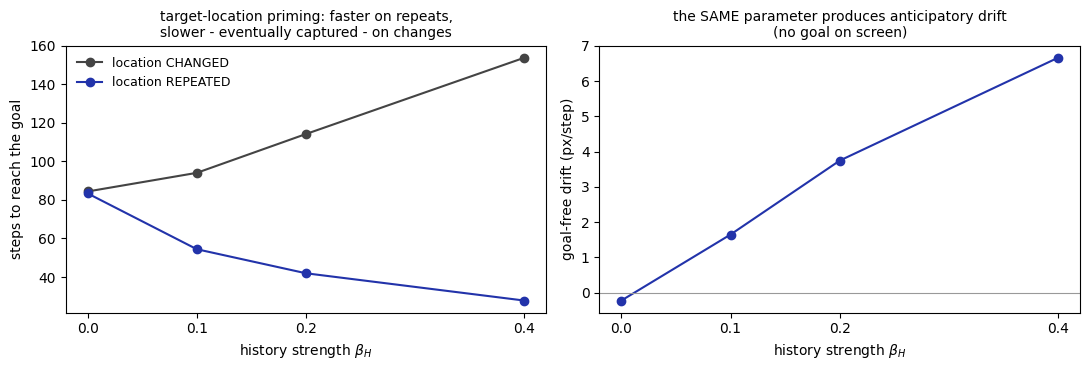

In [11]:
from evaluate_priming import run_seed as priming_run_seed

pargs = SimpleNamespace(num_features=360, num_balls=10, width=W, height=H,
                        max_speed=10.0, goal_timeout=300, goal_free_steps=25,
                        ecc_min=250.0, ecc_max=330.0, num_trials=61)
betas = [0.0, 0.1, 0.2, 0.4]
rep, chg, drift = [], [], []
for b in betas:
    rows = priming_run_seed(model, b, pargs, 42) \
         + priming_run_seed(model, b, pargs, 43)
    def m(kind, idx):
        v = [r[idx] for r in rows if r[0] == kind and r[idx] is not None
             and not (isinstance(r[idx], float) and math.isnan(r[idx]))]
        return sum(v) / len(v)
    rep.append(m("repeat", 1)); chg.append(m("change", 1))
    dv = [r[3] for r in rows if not math.isnan(r[3])]
    drift.append(sum(dv) / len(dv))
    print(f"beta_H {b:.1f}: repeat {rep[-1]:5.1f}  change {chg[-1]:5.1f} steps"
          f"   drift {drift[-1]:+.2f} px/step")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(betas, chg, "o-", color="#444444", label="location CHANGED")
axes[0].plot(betas, rep, "o-", color="#2233aa", label="location REPEATED")
axes[0].set_xlabel(r"history strength $\beta_H$")
axes[0].set_ylabel("steps to reach the goal")
axes[0].set_title("target-location priming: faster on repeats,\n"
                  "slower - eventually captured - on changes", fontsize=10)
axes[0].set_xticks(betas); axes[0].legend(frameon=False, fontsize=9)
axes[1].plot(betas, drift, "o-", color="#2233aa")
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel(r"history strength $\beta_H$")
axes[1].set_ylabel("goal-free drift (px/step)")
axes[1].set_title("the SAME parameter produces anticipatory drift\n"
                  "(no goal on screen)", fontsize=10)
axes[1].set_xticks(betas)
plt.tight_layout()
plt.show()

The full human signature from one parameter (ledger, ~300
trials/beta): at `beta_H = 0` repeat and change are equivalent; as it
grows, repeats speed up (63.9 -> 31.8 steps), changes slow down (56.9
-> 183.7, with outright capture by the remembered location at high
beta - the navigation analog of attentional capture by selection
history), and goal-free drift toward the remembered location rises
from ~0 to 4.3 px/step. Facilitation where the past repeats, cost
where it breaks, anticipation without the goal - one mechanism, one
strength, exactly parallel to the search model's `beta_T`.

## Recap

| The agent receives | It returns |
| --- | --- |
| two LiDAR scans, the goal vector, the remembered-goal vector | a 2D movement |

We introduced the field model and its diagram (Sec. 1), built the
pieces - distance psychophysics, looming, the gain-x-cosine goal and
history fields (Sec. 2) - showed the whole forward pass imported from
the codebase (Sec. 3), cloned the expert with history disabled
(Sec. 4), matched the expert's throughput on the task of record
(Sec. 5), probed never-demonstrated densities and speeds and compared the field
model against MLP and transformer baselines trained on identical
footing (Sec. 6),
and demonstrated target-location priming and anticipatory drift as a
mechanism-sufficiency result: one added history parameter, both
signatures, absent at zero (Sec. 7).

More: `RESULTS_goal_es2.md` (the full experimental record for
this model) and `Visual-Search/tutorial_visual_search.ipynb` (the
companion model of first saccades).